# Basis Construction Timing for 2D $\phi^2$ and $\phi^4$ Theories for Hamiltonian Truncation on a Circle.

Builds the basis for a truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$.

Code used as part of the construction of work arXiv:2607.XXXXX.

References: arXiv:2507.15941, arXiv:2110.08273.

In [1]:
# Calculation imports.
import math
import numpy as np
from collections import Counter

# Plotting Imports.
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scienceplots
%matplotlib inline

# Data Management.
import csv

## 1. Single-particle energy and mode indexing

Modes are identified by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [2]:
def omega(l, mQ, r):
    # State Energy
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    # Global variable storing a list of all state energies.
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

def get_total_occupation_number(state):
    # Returns occupation number for a given state in dictionary format.
    return sum(state.values())

def convert_state_to_list(state, lmax):
    # Returns state held in dictionary to list.
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]


def get_state_energy(state, mQ, r):
    # Returns state energy for state in dictionary format.
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the integer partitions

The integer partitions of a particular integer $n_\text{max}$ are essentially the ways of constructing that number from summing smaller integers. Here, $n_\text{max}$ will ultimately be an angular momentum state.

`gen_parts` builds a dictionary with all of the ways to create a number $n_\text{max}$ by summing smaller numbers. This is stored in the global state `PARTITIONS` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `paritions` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`gen_parition_counter` then turns the global dictionary `PARTITIONS` into a global frequency dictionary `PARTITION_COUNTER`. Elements of `PARTITION_COUNTER` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`gen_partition_energies` computes a list of energies for each set of coins labelled by `l` in `PARTITIONS`. As positive and negative `l` states have the same energy, this only needs computing once.



In [3]:
def gen_parition_counter(partitions):
    #Turns partitions into a global counting dictionary, which is easier to perform operations on.
    global PARTITION_COUNTER
    PARTITION_COUNTER = {}
    for key in partitions.keys():
        PARTITION_COUNTER[key] = [Counter(reversed(val)) for val in partitions[key]]
        

def gen_parts(n_max):
    global PARTITIONS
    # Creates the PARTITIONS dictionary if it does not already exist.
    if 'PARTITIONS' not in globals():
        PARTITIONS = {}
        PARTITIONS.setdefault(1,[[1]]) 
        
    # If we have already calculated up to n_max, just return the dictionary.
    if n_max in PARTITIONS: return(PARTITIONS)
     

    for i in range(max(PARTITIONS.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        PARTITIONS[i] = [cns[:-1]+[cns[-1]+1] for cns in PARTITIONS[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], PARTITIONS[i-1])) 
        
    # Creating a counting dictionary version of this as it is easier to perform operations on.
    gen_parition_counter(PARTITIONS)
    return PARTITIONS


def partition_energies(l,mQ,r):
    #Computes the energies of each possible partition for the state l.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in PARTITIONS[l]]
            

In [4]:
#Example of the paritions. 
gen_parts(4)
#Just printing states 3 and 4.
for i in range(3,5):
    print(f'lmax = {i}')
    for part in PARTITIONS[i]:
        print(f'Partition = {part}, Energy = {sum(map(lambda c: omega(c, 1, 1), part))}')

lmax = 3
Partition = [3], Energy = 3.1622776601683795
Partition = [2, 1], Energy = 3.6502815398728847
Partition = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Partition = [4], Energy = 4.123105625617661
Partition = [2, 2], Energy = 4.47213595499958
Partition = [3, 1], Energy = 4.576491222541475
Partition = [2, 1, 1], Energy = 5.06449510224598
Partition = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `PARTITION_COUNTER`'s together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

To note about this particular method:

1. States are stored in dictionary form i.e. `{l:nl,...}` where `l` is the angular momentum and `nl` is the corresponding occupancy number.

2. This particular method also stores a list of states to iterate over with one in a pair of Z2 antisymmetric states about `l=0` is retained. For example `{-3:1,1:3}` would be asymmetric. For larger `e_max` just less than 1/2 of the states are in Z2 antisymmetric pairs, which have almost identical(*) transition amplitudes so this aids in reducing computation time later.

3. States are produced with the ordering such that `l` goes from most negative to most positive for each state in the basis.

(*) The key difference is the positioning of the results in the matrix, which is taken care of as required.

In [5]:
def gen_basis(lmax, e_max, mQ, r):
    iterSet = set({0}) # Set of states to iterate over when generating the transition matrix.

    #l=0:
    result = [{}] # The empty state.

    for i in range(1, int(math.floor(e_max/mQ)) + 1): # Adding l=0 states up to the maximum possible number allowed before reaching e_max.
        result+=[{0: i}] 
        iterSet.add(i)

    #l>0:
    # ix is the running state index which we set to one above the maximum l=0 occupancy.
    ix = int(math.floor(e_max/mQ))+1
    
    
    for l in range(1,lmax+1):
        gen_parts(l) # All ways of making up to lmax with smaller numbers
        gen_parition_counter(PARTITIONS) # Generates a dictionary version
        partEnergies = partition_energies(l,mQ,r) # Energies for each set of coins.

        # Iterate through positive (ii, ci) and negative (jj, cj) momenta, then merge dictionaries.
        for ii,ci in enumerate(PARTITION_COUNTER[l]):
            for jj,cj in enumerate(PARTITION_COUNTER[l]):
                if jj>=ii: # Only make one copy of each asymmetric state.

                    #Build a temporary energy for the state so we can 
                    # A) figure out if it exceeds e_max.
                    # B) add l=0 states successively up to e_max.
                    e_temp = e_max - partEnergies[ii] - partEnergies[jj]
                    
                    if e_temp > 0: #Fill up l=0 state up to e_max.

                        # Merge positive and negative l states, with total l=0. 
                        negative_cj = {-jjj:cjj for jjj,cjj in reversed(cj.items())} # 'reversed' operation here gives correct l-ordering in the state dictionary. NOTE this is not strictly guaranteed to be maintained.
                        
                        
                        result+=[ negative_cj | ci ]
                       
                        # Add to the iterSet and increase state index.
                        iterSet.add(ix)
                        ix += 1

                        if ii!=jj: 
                            # Merge the Z2 reversed dictionaries.
                            negative_ci = {-iii:cii for iii,cii in reversed(ci.items())}
                            result += [ negative_ci | cj ]
                        
                            # Increase state index but do not add to iterSet.
                            ix += 1



                        # Now adding successively more l=0 states up to total e_max.
                        for i in range(1, int(math.floor(e_temp/mQ)) + 1):

                            # Adding successively more l=0 states up to e_max in the center of the dictionary.
                            result+=[ negative_cj | {0:i} | ci ]
                            
                            iterSet.add(ix)
                            ix += 1
                            
                            if ii!=jj: 
                                # Merge the Z2 reversed dictionaries.
                                result += [ negative_ci | {0:i} | cj ]
                                ix += 1
                            
                        
                
    return (result, iterSet)

In [6]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

## 3. Basis Generation Timing Between 2110.08273 Method and New Method

Must compute the timing with 2110.08237 in a different notebook and import as "benchmark_basisgen_results.csv"

In [7]:
# ---------------------------------
# ---- Prepatation and Inputs -----
# ---------------------------------

# Hamiltonian Parameters.
mQ = 1.; r = 1.
#Test Range of E_max.
emax_basisgen_part = range(10,40)

# Lists to hold the timing result and basis lengths.
execution_basisgen_part = []; len_basis = []

if 'PARITIONS' in globals():
    #For fairness, reset the PARTITIONS dictionary at the beginning (and each time after).
    del PARTITIONS 

# ---------------------------------
# --- Running the data creation ---
# ---------------------------------


# 1. Iterate over emax_list
for emax in emax_basisgen_part:
    print(f"E_max: {emax}")
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    
    # Using timeit to get accurate generation timings.
    duration = %timeit -o gen_basis(lmaxeff,emax,mQ,r)
    # Generating the basis via the above method so we can find it's length.
    basis,_ = gen_basis(lmaxeff,emax,mQ,r)
    
    # Adding execution timings and full basis length to the result.
    execution_basisgen_part.append(duration.average)
    len_basis.append(len(basis))
    
    del PARTITIONS #For fairness, reset the PARTITIONS dictionary each time.
    

# 2. Export results to a CSV file
csv_filename = "partition_basisgen_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, r = {r}") # Hamiltonian Parameters Recorded
    writer.writerow("EMax List")
    writer.writerow(emax_basisgen_part) # List of emax Recorded
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_basisgen_part,execution_basisgen_part))

E_max: 10
62.6 μs ± 468 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 11
112 μs ± 946 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 12
135 μs ± 706 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 13
229 μs ± 1.83 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 14
282 μs ± 1.07 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 15
463 μs ± 4.17 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 16
556 μs ± 2.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 17
879 μs ± 8.83 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 18
1.09 ms ± 9.74 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 19
1.68 ms ± 14.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 20
2.14 ms ± 15.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_max: 21
3.15 ms ± 19.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
E_m

--- Benchmark Params ---
mQ = 1, r = 1.0


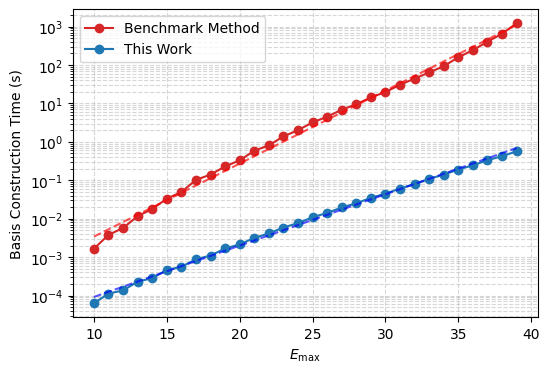

In [8]:
# ---------------------------------
# ------- Running the plot --------
# ---------------------------------


# 1. Importing comparison timings.
#This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_basisgen_bench = []; emax_basisgen_bench = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_basisgen_bench = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_basisgen_bench.append(float(row[1])) # Convert time back to float



# 2. Linear Fits
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_bench = (np.polyfit(emax_basisgen_bench[startix:], np.log10(execution_basisgen_bench)[startix:], 1))
coef_partition = (np.polyfit(emax_basisgen_part[startix:], np.log10(execution_basisgen_part)[startix:], 1))

poly_bench = np.poly1d(coef_bench)
poly_partition = np.poly1d(coef_partition)
xs_bench = np.linspace(emax_basisgen_bench[startix],emax_basisgen_bench[-1])
xs_partition = np.linspace(emax_basisgen_part[startix],emax_basisgen_part[-1])


        

# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Basis Construction Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_basisgen_bench, execution_basisgen_bench, marker ='o', linestyle='-', color='tab:red', label='Benchmark Method')
ax1.plot(
    xs_bench, 10**poly_bench(xs_bench),
    '--', color='r', alpha=0.66
)
ax1.plot(emax_basisgen_part, execution_basisgen_part, marker ='o', linestyle='-', color='tab:blue', label='This Work')
ax1.plot(
    xs_partition, 10**poly_partition(xs_partition),
    '--', color='b', alpha=0.66)
plt.legend()

plt.savefig('basis_construction_comparison.pdf',format='pdf')


## 3. State Occupation Plot

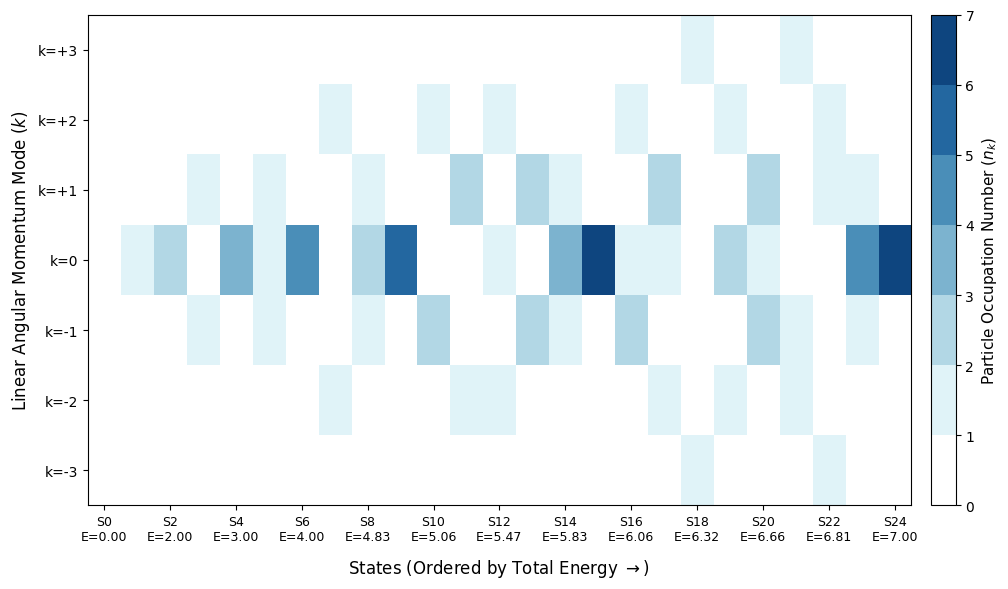

In [9]:
# ---------------------------------
# --- Setting Plot Parameters -----
# ---------------------------------

mQ = 1; r = 1.; e_max=7

# ---------------------------------
# ----- Generating the Basis ------
# ---------------------------------

# Effective maximum momentum state.
lmaxeff = effective_lmax(e_max,e_max,mQ,r)
# Generate the basis.
basis, iterList = gen_basis(lmaxeff,e_max,mQ,r)


# List of Possible Angular Momenta.
modes = list(range(-lmaxeff, lmaxeff+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
# Computing the energies
state_energies = []
for state in basis:
    state_energies.append(sum([nl*omega(l, mQ, r) for l, nl in state.items()]))

# Sorting the states by energy.
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# ---------------------------------
# ------- Running the plot --------
# ---------------------------------


fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP for the plot. Add more colours if more than 10 occupation number required.:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes] # Separating positive and negative angular momenta.
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    # Reducing the number of state labels if it becomes too large, as unreadable.
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)

ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)


# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()